# XGBoost basic syntax and model explanation
## Data
Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]

Individual medical costs billed by health insurance

EDA: e.g [https://datauab.github.io/medical_insurance/]

In this notebook, we will demonstrate basic syntax of XGBoost library.

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements machine learning algorithms under the Gradient Boosting framework.

As boosting models (similarly as most of other ensemble modes) are blac box models, we will use SHAP values to open the black box and explain the model and its predictions.


In [1]:
#Dependencies
import xgboost as xgb #pip3 install xgboost
import pickle
import numpy as np
import shap
import matplotlib.pyplot as plt


#Usefull functions
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import PartialDependenceDisplay

SEED = 500

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# import gdown
#In colab, you need to download the file first and save it locally
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
# file_path = 'insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9
To: /content/insurance_train_test.pkl
100%|██████████| 74.0k/74.0k [00:00<00:00, 55.5MB/s]


'insurance_train_test.pkl'

We will use the insurance data preprocessed and stored in the pickle file again.

In [ ]:
#Load the data
#for local installation / VM horizon
file_path = '../data/insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train,X_test, y_train, y_test = pickle.load(input_file)

## First XGBoost model
- First we will fit a XGBoost model with some hyper parameters that fell off the sky. (The Fenster's method ;-))
- You can use a scikit wrapper which allows using analogous synax to other popular scikit models (e.g. DecisionTreeRegressor or RandomForestRegressor...)
- This is the usual instantiate -> fit -> predict sequence.
- The HP can again be inputed directly at the instantiation of the model or you can use a dictionary and pass in the dictionary.
- Alternativelly, you can use directly the XGBoost syntax. In that case, you first need to transform the data into a dmatrix format.

In [ ]:
#Using dictionary with HP
prms = {"n_estimators":50, "learning_rate": 0.1}

#Instantiate a xgb.XGBRegressor
mod_xgb0 = xgb.XGBRegressor(**prms, objective='reg:squarederror',seed = SEED)

#Or use directly the parameters in the function
#mod_xgb0 = xgb.XGBRegressor(n_estimators = 50, learning_rate = 0.1, objective='reg:squarederror',seed = SEED)

#Fit XGBoost with SciKit wrapper
mod_xgb0.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Alternativelly, use directly XGBoost syntax, xgb.train(dtrain = train_dmatrix, params = params) but Dmatrix needs to be created


In [ ]:
# Predict the test set labels 'y_pred0'
y_pred0 = mod_xgb0.predict(X_test)

# Evaluate the test set RMSE
rmse_test0 = root_mean_squared_error(y_test, y_pred0)
print(rmse_test0)

4025.302978515625


# HP optimization
We can optimize the HP.
We can use e.g. grid search and find the best parameters found using the cross validation.

In [ ]:
#setup params grid
param_grid = {'learning_rate': [0.01,0.1,0.5], #alias eta, Step size shrinkage used in update to prevents overfitting.
    'n_estimators': [20, 50, 100],
    'subsample': [0.5, 0.8, 1], #Subsample ratio of the training instances
    'max_depth': [3, 5, 10],
    'colsample_bytree': [0.5, 1] #colsample_bytree is the subsample ratio of columns when constructing each tree. Subsampling occurs once for every tree constructed.
    }

#instantiate XGBRegressor
mod_xgb_gs = xgb.XGBRegressor(seed=SEED, objective='reg:squarederror')
grid_mse = GridSearchCV(estimator=mod_xgb_gs,
                        param_grid=param_grid,
                        scoring='neg_mean_squared_error',
                        cv=3,
                        verbose=1,
                        n_jobs=-1)
#fit  GridSearchCV
grid_mse.fit(X_train, y_train)

print("Best parameters found: ",grid_mse.best_params_) #best_params_
print("Lowest in-sample loss found: ", np.sqrt(np.abs(grid_mse.best_score_))) #best_score_



Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best parameters found:  {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Lowest in-sample loss found:  4754.197583890122


In [ ]:
#extract the estimator best_estimator_
mod_xgb = grid_mse.best_estimator_ #best_estimator_

# Predict the test set labels 'y_pred'
y_pred = mod_xgb.predict(X_test)

# Evaluate the test set RMSE
rmse_test = root_mean_squared_error(y_test, y_pred)
print(rmse_test)

3604.280517578125


You may also use random search.

Note that there are lot of hyoper parameters and other options that can be tweaked: [https://xgboost.readthedocs.io/en/stable/parameter.html]. But not all of them are equally important.

There are several recommendations but...Typically it is necessary to focus at least on
- n_estimators
- learning rate
- max depth
- subsample
- colsample_bytree

There are also recommendations to avoid complete grid:
[https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/]

There are more advanced methods to find optimal combination. For example Optuna uses bayesian optimization techniques: [https://forecastegy.com/posts/xgboost-hyperparameter-tuning-with-optuna/]

Or even special purpose algorithms [https://sylwiamielnicka.com/blog/xgboost-tune-it-automatically/]

# SHAP values and model explanation
- SHAP values are used to explain the output of machine learning models.
- SHAP plots description: [https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html]

In [ ]:
# Create a SHAP explainer
explainer = shap.Explainer(mod_xgb)
# Calculate SHAP values on test data
shap_values = explainer(X_test)
#The shape of the SHAP values is (n_samples, n_features)
print("Shape of data: ", X_test.shape)
print("Shape of SHAP values matrix: ",shap_values.shape)

Shape of data:  (268, 9)
Shape of SHAP values matrix:  (268, 9)


## Local interpretability with SHAP values
SHAP values can be used to explain the prediction for a **single observation or for the model as a whole**. In case of a single observation, we talk about **local interpretability**. In case of the model as a whole, we talk about **global interpretability**.


**Task:**

Confirm that sum of the SHAP values for all features is equal to the difference between the model output for a given sample and the average model output over the training dataset. Use a single observatiopn from the row 50 of the training sample.


In [ ]:
analyze_sample_id = 50 #pick an observation (row)
print("Input data: ", X_train.iloc[[analyze_sample_id]])
print("The base value: ", explainer.expected_value) #The base value or the expected value is the average of the model output over the training data
print("The prediction: ", mod_xgb.predict(X_test.iloc[[analyze_sample_id]]))

Input data:       age   bmi  children  sex_male  smoker_yes  region_northeast  \
954   34  27.8         1      True        True             False   

     region_northwest  region_southeast  region_southwest  
954              True             False             False  
The base value:  13571.791
The prediction:  [39058.145]


In [ ]:
#Sum of SHAP values for all features + base value = prediction
print("Sum of base value and shap values: ", shap_values.values[analyze_sample_id].sum() +  shap_values.base_values[analyze_sample_id]) #equals prediction

Sum of base value and shap values:  39058.15


You can produce **force plot** or **watterfall plot** to vizualize the explanation of one specific prediction.

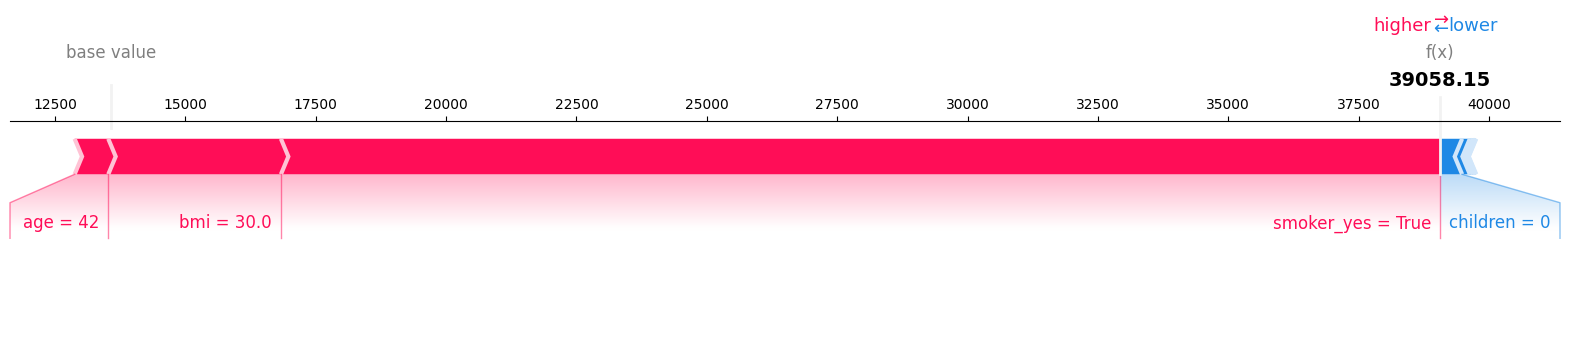

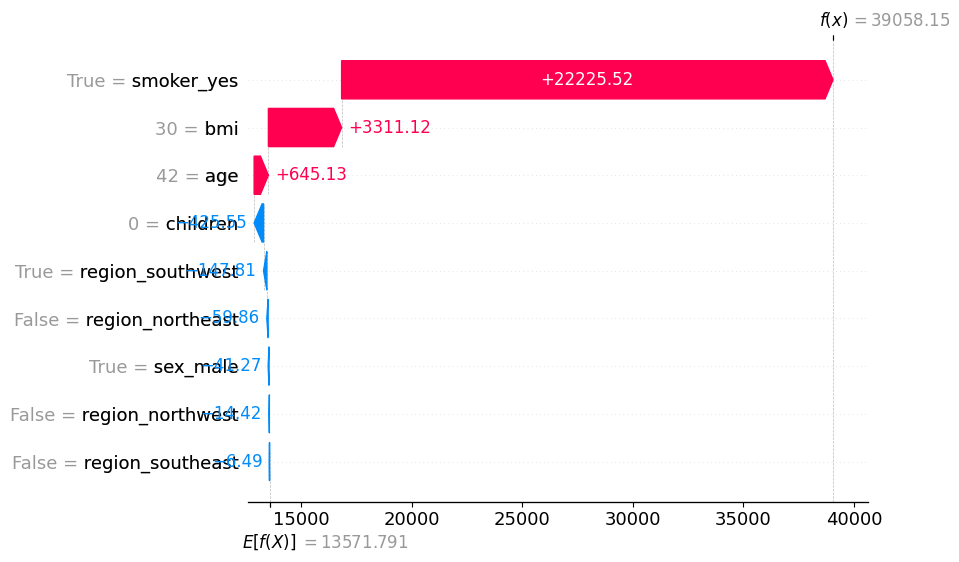

In [ ]:
#shap.initjs() # load JS visualization code to notebook - run this line for default javascript output or use matplotlib = True
#Force plot
shap.plots.force(shap_values[analyze_sample_id], matplotlib = True)

#Waterfall plot
shap.waterfall_plot(shap_values[analyze_sample_id])

## Global interpretability with SHAP values
Now we interpret the predictions with some aggregate measures and vizualisations based on the SHAP values to explain the model as a whole.

Vizualizations are a popular tool for this task. You can use **Beeswarm plot** or the SHAP **importance plot**.



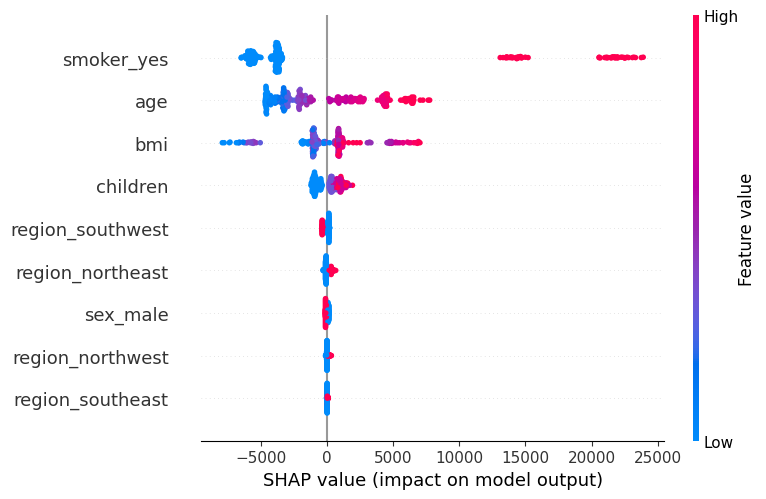

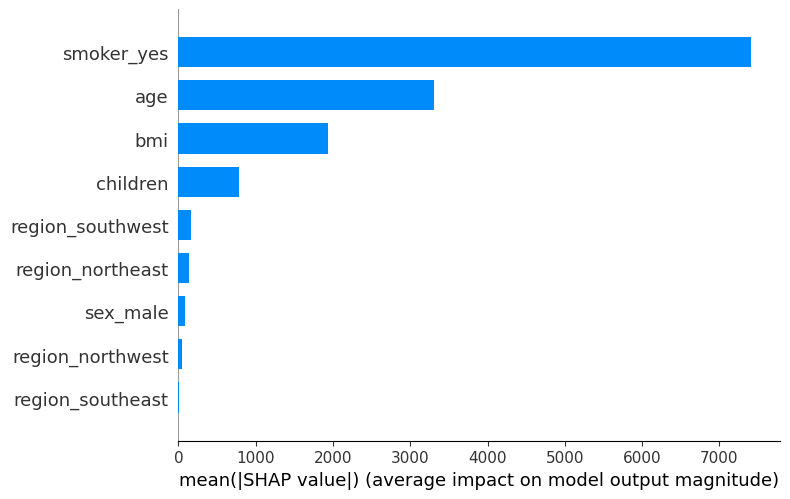

In [ ]:
#Global explanation##
#SHAP beeswarm plot
shap.summary_plot(shap_values, X_test)

#SHAP importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Further notes

XGBoost builds decision trees by splitting features based on thresholds. These splits depend only on the order of feature values, not their absolute magnitudes. Scaling or standardizing features does not change the order, so it has no effect on how trees are constructed.

While XGBoost uses gradients and Hessians during optimization, these are computed for determining the weights of leaf nodes and updating residuals. The computation of these values is independent of feature scaling because the splits (which define the tree structure) are already determined by the feature order.

SHAP Values and Feature Scaling: SHAP values are designed to provide insights into the contribution of each feature to the model's predictions. They are derived from the model's output and do not depend on the scale of the input features when using tree-based methods. Therefore, you can interpret SHAP values directly from unstandardized features without losing their meaning or accuracy.

Magnitude of SHAP Values: SHAP values quantify the contribution of each feature to a model's prediction. The magnitude of these values reflects how much a feature influences the prediction. If a feature has a larger scale, its changes can lead to larger absolute SHAP values, making it appear more important in the context of the model's predictions.

For models with features in vastly different units, standardized SHAP values can provide a dimensionless measure of importance to complement the explanation.

### One hot encoded variables
For one hot encoded categorical variables, each binary dummy variable will have its own SHAP value.
This can make it difficult to interpret the overall contribution of the original categorical feature.

SHAP values are **additive**, meaning that summing them over some features or rows has sense.



New shap values shape:  (268, 6)


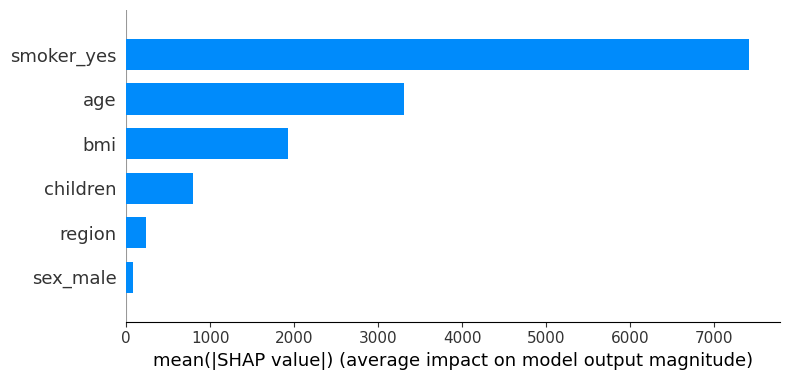

In [ ]:
#Columns with name starting with string "region_"
region_cols = [col for col in X_train.columns if col.startswith('region_')]
#Get the SHAP values for the region variables
shap_values_region = shap_values.values[:,X_train.columns.isin(region_cols)]
#sum the SHAP values for the region variables
shap_values_region_sum = np.sum(shap_values_region, axis=1)

#Add the sum of the SHAP values for the region variables to the SHAP values for the other variables
shap_values_region_sum = np.column_stack((shap_values.values[:,~X_train.columns.isin(region_cols)], shap_values_region_sum))
#Check the shape of the new SHAP values matrix (9-4 regions + 1 sum of regions = 6)
print("New shap values shape: ", shap_values_region_sum.shape)
#New column names
new_columns = list(X_train.columns[~X_train.columns.isin(region_cols)]) + ["region"]
#New summary plot
shap.summary_plot(shap_values_region_sum, feature_names=new_columns, plot_type="bar")

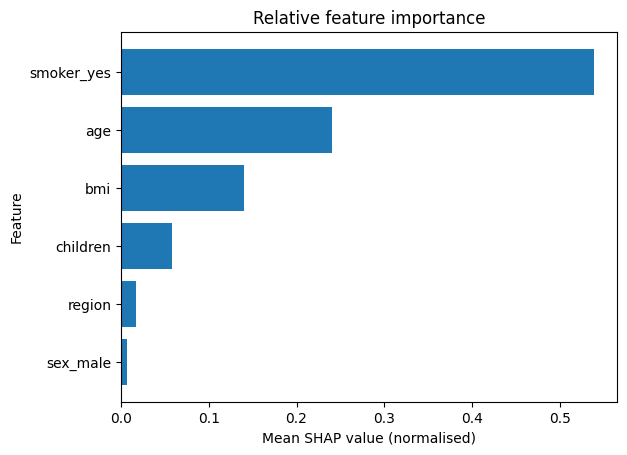

In [ ]:
#Calculate the shap importance as mean absolute SHAP values
shap_importance_norm = np.abs(shap_values_region_sum).mean(0)
#Normalise the mean abs SHAP values
shap_importance_norm = shap_importance_norm / shap_importance_norm.sum()
#Sort the normalised SHAP values
shap_importance_norm, new_columns = zip(*sorted(zip(shap_importance_norm, new_columns)))
#Barplot shap_values_norm
plt.barh(new_columns, shap_importance_norm)
plt.xlabel("Mean SHAP value (normalised)")
plt.ylabel("Feature")
plt.title("Relative feature importance")
plt.show()


## XGBoost importance
You may also use the feature importance functions built in the XGBoost libray.

There are several types of importance, weight, gain, cover

- Weight: Counts the absolute number of times a feature is used in any split across all decision trees in the model. It  does not account for how much each split improves the model's performance. A feature might be used frequently but have little actual impact on predictive power.

- Gain is the improvement in accuracy brought by a feature to the branches it is on. The idea is that before adding a new split on a feature X to the branch there were some wrongly classified elements; after adding the split on this feature, there are two new branches, and each of these branches is more accurate (one branch saying if your observation is on this branch then it should be classified as 1, and the other branch saying the exact opposite).

- Cover is related to the second order derivative (or Hessian) of the loss function with respect to a particular variable; thus, a large value indicates a variable has a large potential impact on the loss function and so is important.

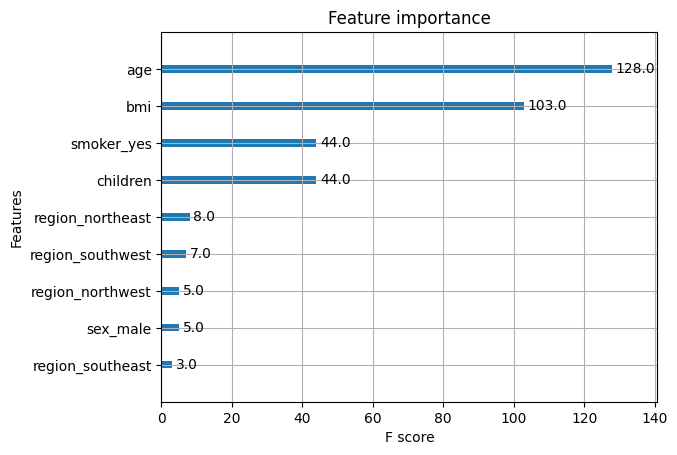

In [ ]:
xgb.plot_importance(mod_xgb, importance_type='weight') #type='weigt' is the default
plt.show()

### Shap dependence plot
The dependence plot shows the effect of a single feature across the whole dataset.

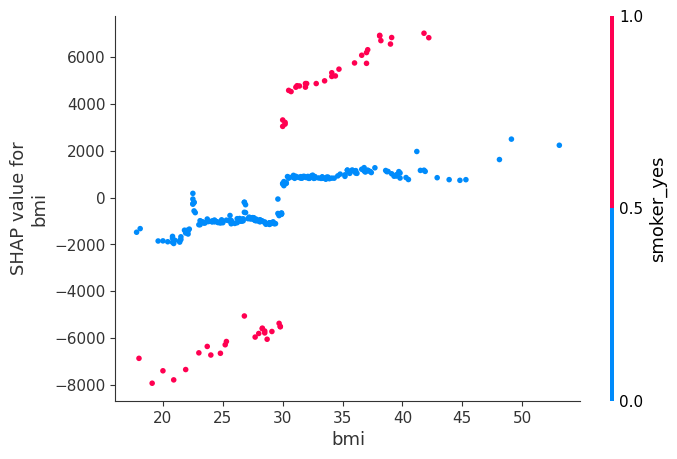

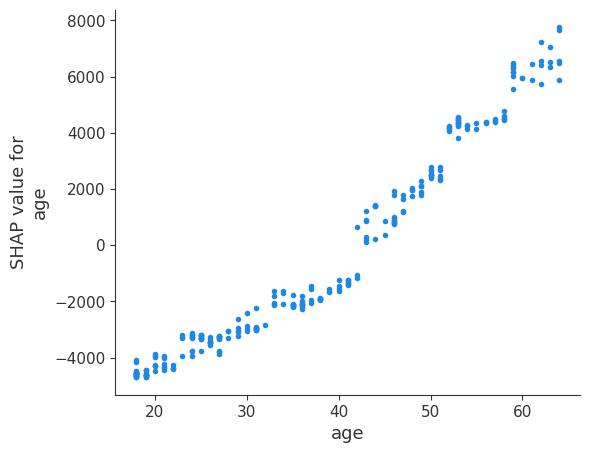

In [ ]:
#SHAP Dependence plot
shap.dependence_plot('bmi', shap_values.values, X_test) ##The function automatically includes another variable that your chosen variable interacts most with.
#e.g. for bmi, smoker_yes is selected (set no interactions by None, or specify the interaction_index)
shap.dependence_plot('age', shap_values.values, X_test, interaction_index=None) #no interaction

## Partial dependence plot (Sklearn)
Sklearn allows doing similar vizualizations called Partial dependence plots.

You can construct 2D or even 3D  plots.

Partial dependence plot shows the marginal effect of a feature on the predicted outcome of the model.
[https://scikit-learn.org/stable/auto_examples/inspection/plot_partial_dependence.html]

PartialDependenceDisplay.from_estimator(estimator, X, features)

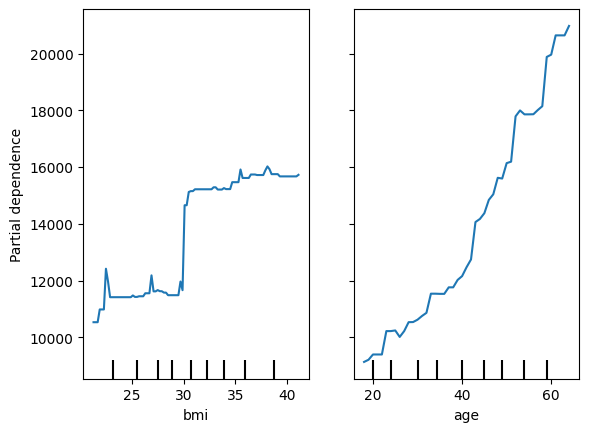

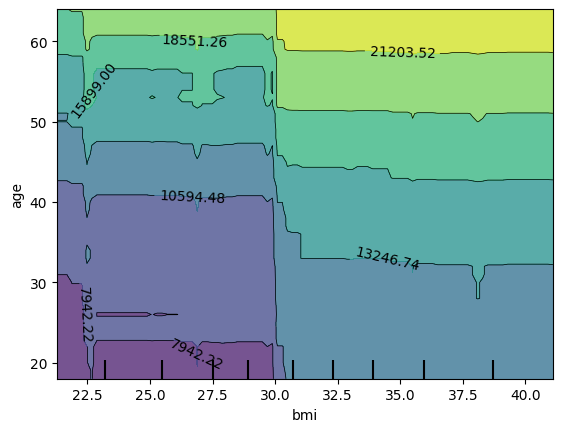

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

#single pdp plots for "bmi" and "age"
PartialDependenceDisplay.from_estimator(mod_xgb, X_train, features = ["bmi", "age"])

#Two-dimensional (tuple) ("bmi", "age")
PartialDependenceDisplay.from_estimator(mod_xgb, X_train, features = [("bmi", "age")])

**Tasks:**

1) What can you say about the dependence of the charges on the age with respect to sex?
2) What can you say about the correlation between the charges and the age?
3) Based on the SHAP value plots, what can you say about the correlation between the charges and the region?
4) Pick randomly 3 rows in the test set and explain the prediction using SHAP values.
5) Use SHAP values to explain the prediction for the sample with the highest and lowest predicted charge in the test set.
6) Use SHAP values to explain the prediction for the sample with the highest residual in the test set.

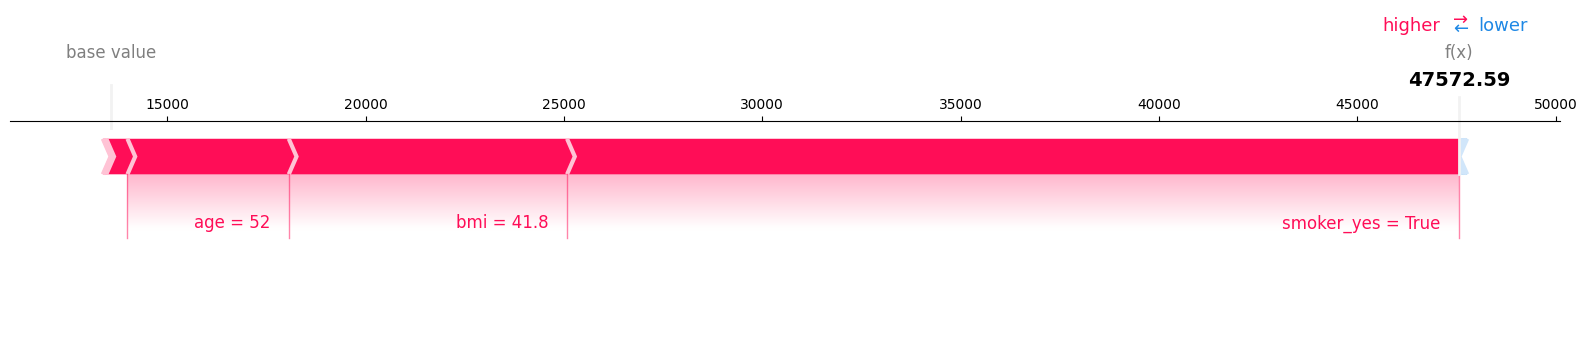

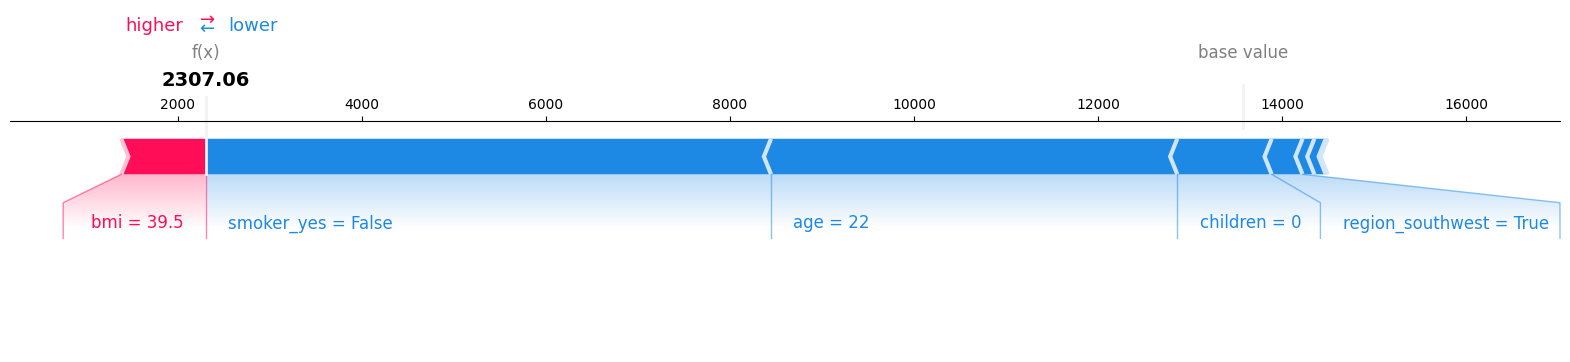

In [ ]:
def explain_selected(idx):
    #Get the observation
    obs = X_test.iloc[[idx]]
    #Get the SHAP values for the observation
    shap_values_obs = shap_values[idx]
    #Force plot for the observation
    shap.plots.force(shap_values_obs, matplotlib = True)

#Explain the observation with index 50
explain_selected(np.argmax(y_pred))
explain_selected(np.argmin(y_pred))

Index with the highest residual:  23


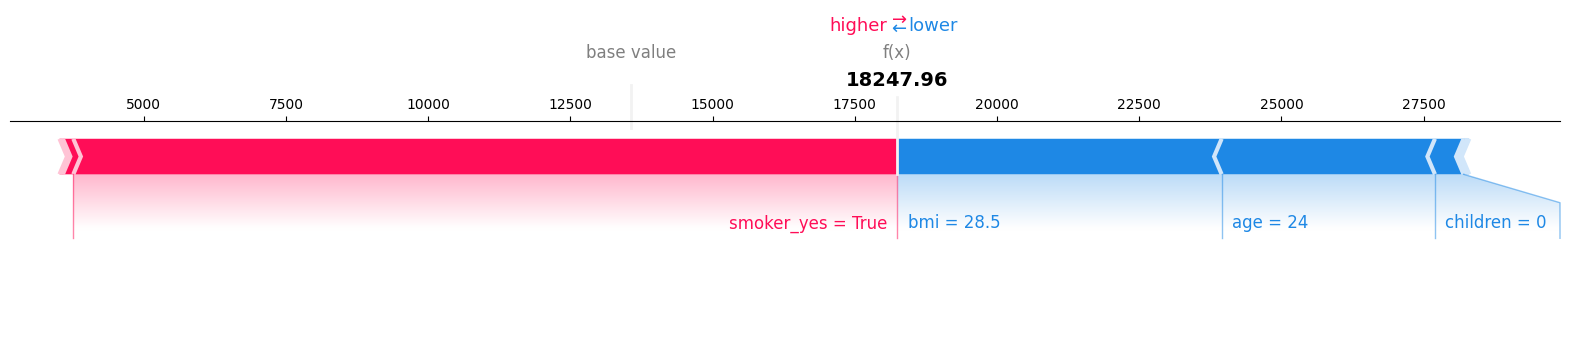

charges    35147.53
Name: 476, dtype: float64
18247.969
16899.56125


In [ ]:
#Find row index with the highest charge value in the test set
residuals = y_test.values.reshape(1,-1) - y_pred
idx = np.argmax(residuals)
print("Index with the highest residual: ", idx)
#Explain the observation with the highest residual
explain_selected(idx)

print(y_test.iloc[idx])
print(y_pred[idx])
print(residuals[0][idx])

This client has very high charges despite he has low bmi, he is young and has no children. The prediction is above average prediction (the base value) because he is a smoker. But the observed charges extreme. It seems the prediction is ok and the high residual is really random.